# Reconstruction of the dynamical system in 3D

## Setup

### Packages and functions

In [1]:
using LinearAlgebra, GLMakie
using StatsBase: mean, sample, wsample, median, msd
import Random

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

ax3d(f;azymuth=0.4pi,kwargs...) = # 0.7pi or 0.4pi
    Axis3(
        f, viewmode=:fitzoom, aspect=:data, azimuth=azymuth,
        xlabel=varnames[1], ylabel=varnames[2], zlabel=varnames[3],
        protrusions=(30,0,30,0)
    )

ax3d (generic function with 1 method)

### Makie theme

In [2]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Model definition

In [61]:
varnames = ["x","y","z"]
#modelname = "FeedbackLoop"
modelname = "LorenzSystem"

if modelname == "LorenzSystem"
    f(x,y,z; p=10, r=28, b=8/3) = [-p*x + p*y, -x*z + r*x - y, x*y - b*z]
else # "Feedback loop"
    hf(x;n=2) = 1/(1+x^n) # hill-like function
    #f(x,y,z;a=1,b=1,c=1) = [hf(z;n=20)-a*x,x-b*y,y-c*z]
    f(x,y,z;a=1,b=1,c=1) = [hf(z;n=12)-a*x,x-b*y,y-c*z/(1+z)]
end

vf(x) = f(x...)

vf (generic function with 1 method)

## Simulate trajectories

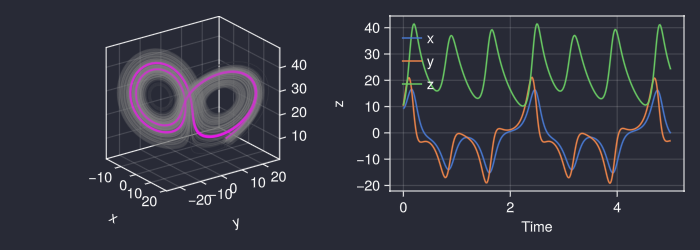

In [62]:
N = 2000
ns = 500
dt = modelname == "LorenzSystem" ? 0.01 : 0.1
init = modelname == "LorenzSystem" ?
    () -> randn(3) + fill(10.,3) :
    () -> rand(0..2,3)

cpal = resample_cmap(:seaborn_muted,10)
Random.seed!(111)
trajs = [kutta(spa(f),init(),s=ns,dt=dt) for _ in 1:N]

let
    fig = Figure(size=(700,250),)
    ax1 = ax3d(fig[1,1],title=modelname,azymuth=-0.2pi)
    for i in sample(1:N,100)
        lines!(ax1,Point3f.(eachcol(trajs[i])),color=:grey,transparency=true,linewidth=0.1,rasterize=2)
    end
    lines!(ax1,Point3f.(eachcol(last(trajs))),color=:magenta,transparency=true,linewidth=2)
    ax2 = Axis(fig[1,2],xlabel="Time")
    [lines!(ax2,0:dt:dt*ns,last(trajs)[i,:],label=varnames[i],color=cpal[i]) for i in 1:3]
    axislegend(ax2,position = :lt)
    fig
end

### the movie

In [63]:
vio = let lw=3, tmax=ns, tshow=10, by=1, ishow=sample(1:N,10)
    trsp = true # transparency
    time = Observable(0.0)
    traj = Observable(Point3f[])
    amps = [Observable(Point2f[]) for _ in 1:3]
    cols = Observable(Int[])
    with_theme(theme_dark(),fontsize=14,backgroundcolor=RGBf([36,37,46]/255...)) do
        fig = Figure(size=(900,400))
        ax1 = ax3d(fig[1,1],azymuth=-0.2pi)
        for i in ishow
            lines!(ax1,Point3f.(eachcol(trajs[i])),color=:white,transparency=trsp,linewidth=0.1)
        end
        ln = lines!(ax1,traj,transparency=trsp,linewidth=lw,color=cols,colormap=Reverse(:deep))
        ax2 = Axis(fig[1,2],xlabel="Time (sec.)",limits=(0,dt*tmax,extrema(trajs[tshow][1:3,:])...))
        [lines!(ax2,amps[i],label=varnames[i],color=cpal[i]) for i in 1:3]
        axislegend(ax2,position=:rb)
        vio = Record(fig, 1:by:tmax; framerate=30, profile ="high") do i
            time[] = dt*i
            push!(cols[],i)
            push!(traj[],Point3f(trajs[tshow][1:3,i]))
            i > 100 && popfirst!.([traj[],cols[]])
            [push!(amps[j][],Point2f(time[],trajs[tshow][j,i])) for j in 1:3]
            notify.([traj,cols,amps...])
        end
    end
end

VideoStream(Base.PipeEndpoint(RawFD(82) open, 0 bytes waiting), Process(setenv(`/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin/ffmpeg -y -loglevel quiet -threads 48 -framerate 30 -pixel_format rgb24 -f rawvideo -s:v 900x400 -r 30 -i pipe:0 -vf vflip -profile:v high -crf 20 -preset slow -c:v libx264 -pix_fmt yuv420p -an '/tmp/jl_p7Fr5Q/##video#234.mp4'`,["OPENBLAS_MAIN_FREE=1", "XKB_CONFIG_ROOT=/home/kazumitsu.maehara/.julia/artifacts/23d821271a00e164eb2b5c273985da44f9a831a1/share/X11/xkb", "PATH=/home/kazumitsu.maehara/.julia/artifacts/b8a470e4553346122607f94ec60d83c77f061cd6/bin:/home/kazumitsu.maehara/.julia/artifacts/020f522505f193c968b0a9d6199f7de2c4748cd2/bin:/home/kazumitsu.maehara/.julia/artifacts/cc3c4d36f2cf650d73959f9d7dec5cd0630bfb01/bin:/home/kazumitsu.maehara/.julia/artifacts/258f7271ca555a7634c0fe8b8508f69334673a89/bin:/home/kazumitsu.maehara/.julia/artifacts/c8a20a2030f10b70947d8d2a6bff7f8b5f343fe9/bin:/home/kazumitsu.maehara/.julia/artifacts/100f53309066fcdee2a61044b118ed3342683b67/bin:/home/kazumitsu.maehara/.julia/artifacts/bdb4015047b09c6ac5002f73dfd5be8ddf59189b/bin:/home/kazumitsu.maehara/.julia/artifacts/c9533bea1f28a1adea8cb096009f360534f7ba90/bin:/home/kazumitsu.maehara/.julia/artifacts/48d69f95e00f33788b0bddee11ce58dd15ba21e5/bin:/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin:/usr/local/packages/mambaforge/bin", "JULIA_PROJECT=@.", "JPY_SESSION_NAME=/home/kazumitsu.maehara/pynb/ddHodge_figures/notebook/sim3D_fig.ipynb", "DISPLAY=:1", "COLUMNS=80", "JUPYTERHUB_BASE_URL=/", "SHELL=/bin/bash", "JUPYTERHUB_OAUTH_ACCESS_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]"  …  "LINES=30", "JUPYTERHUB_DEFAULT_URL=/lab", "LIBDECOR_PLUGIN_DIR=/home/kazumitsu.maehara/.julia/artifacts/38e215c51e5c0f77bc7a8813ba4586632a8fc750/lib/libdecor/plugins-1", "HOME=/home/kazumitsu.maehara", "JUPYTERHUB_USER=kazumitsu.maehara", "JUPYTERHUB_CLIENT_ID=jupyterhub-user-kazumitsu.maehara", "JUPYTERHUB_COOKIE_HOST_PREFIX_ENABLED=0", "JUPYTERHUB_OAUTH_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JUPYTERHUB_SERVICE_PREFIX=/user/kazumitsu.maehara/", "JUPYTERHUB_PUBLIC_URL="]), ProcessRunning), GLMakie.Screen(...), Makie.TickController(Observable(Makie.Tick(Makie.OneTimeRenderTick, 500, 16.666666666666668, 0.03333333333333333)), 501, 0.03333333333333333, true, ObserverFunction defined at /home/kazumitsu.maehara/.julia/packages/Makie/4JW9B/src/ffmpeg-util.jl:199 operating on Observable(Tick(OneTimeRenderTick, 500, 16.6667, 0.0333333))), ColorTypes.RGB{FixedPointNumbers.N0f8}[RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0); RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0); … ; RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0); RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0)], "/tmp/jl_p7Fr5Q/##video#234.mp4", Makie.VideoStreamOptions("mp4", 30, 20, "high", "yuv420p", 0, "quiet", "pipe:0", true))

## Uniform sampling on the trajectories

In [64]:
Random.seed!(111)
X = if modelname=="Hamiltonian"
    stack([trajs[i][:,rand(1:ns)] for i in 1:N])
else
    let warmup = 50
        stack([trajs[i][:,rand(warmup:ns)] for i in 1:N])
    end
end

#X = X[:,X[2,:] .> 10]; N = size(X,2)

pts = Point3f.(eachcol(X))
# PCA for visualization
μ = mean(pts)
S = svd(X.-μ).U[:,1:2] #*diagm([-1,1])
Xe = S'*(X.-μ)
pts2 = Point2f.(eachcol(Xe))
V = mapslices(vf,X,dims=1)

3×2000 Matrix{Float64}:
  76.9611   43.783   67.5639  -18.9579  …  -24.2764    23.6933  -16.1116
  40.5459  208.963  141.088   -36.7432       7.14676   42.9089  -13.6154
 -93.0672   68.118  -26.8215  -21.9575     -61.8293   -16.8     -44.7879

## ddHodge workflow

In [65]:
using ddHodge
struct Params
    k::Int
    d::Int
    λ::AbstractFloat
    ϵ::AbstractFloat
end
#par = Params(20,2,0.1,1.0)
par = Params(12,2,1.,10.0)
#par = Params(20,3,0.1,1.0)
g, kdtree = kNNGraph(X,par.k)
ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=1,krytol=1e-32)

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.207 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.9887041324633411
[ Info: ... done in 0.429 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.105 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.9955097172525083
[ Info: ... done in 3.877 sec.


:::ddHodge::: values over graph {2000, 14253}, dimensions: 3 -> 2 (ssa: on)

## Show results

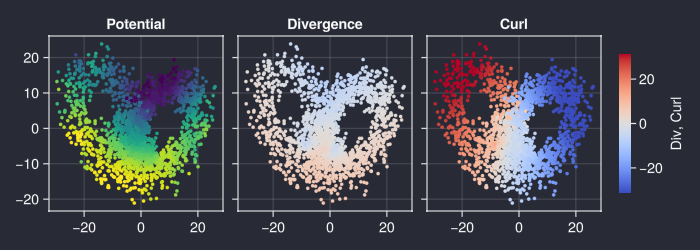

In [66]:
let ms = 5
    fig = Figure(size=(700,250))
    titles = ["Potential", "Divergence", "Curl"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:length(titles)]
    scatter!(axs[1], pts2, color=clip(ddh.u), colormap=:viridis, markersize=ms)
    vmax = clipmax([ddh.rot;ddh.div],p=0.05)
    plt = scatter!(axs[2], pts2, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax))
    scatter!(axs[3], pts2, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax))
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    colgap!(fig.layout,10)
    Colorbar(fig[1,4],plt,height=Relative(0.8),label="Div, Curl")
    fig
end

n2s[2:3] / n2s[1] = [0.23606462495185407, 0.7639353750481459]


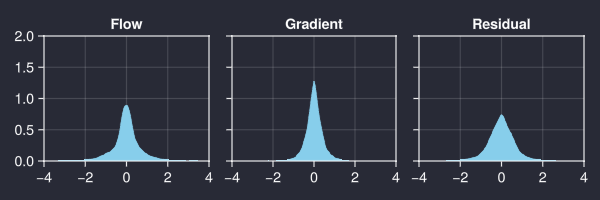

In [67]:
let
    fig = Figure(size=(600,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]/sqrt(mean(abs2.(ddh.w)))
    n2s = norm.(values).^2
    @show (n2s[2:3]/n2s[1])
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    #[hist!(axs[i], values[i], bins=200, color=:skyblue,normalization=:pdf,rasterize=2) for i in 1:3]
    [density!(axs[i], values[i], rasterize=2, color=:skyblue) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    xlims!.(axs,-4,4)
    ylims!.(axs,0,2)
    linkaxes!(axs...)
    fig
end

## Projecting analytical ... may success

In [68]:
import ForwardDiff
Jf(x) = ForwardDiff.jacobian(spa(f),x)

Jf (generic function with 1 method)

2×2 Matrix{Float64}:
 1.38896  1.9708
 2.03753  2.42646

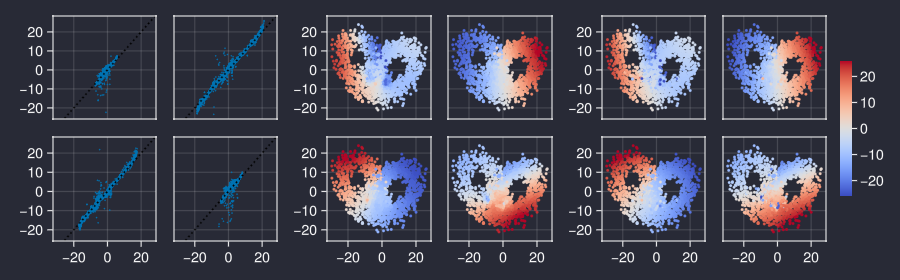

In [69]:
let
    E = Matrix(1.0I,3,3) # cannonical basis
    Ja = [basischange(Jf(pts[i]),E,ddh.frames[i]) for i in 1:N]
    getelm(x;i,j) = x[i,j]
    display(sum([(Ja[i] - ddh.J[i]).^2 for i in 1:N])/N) # MSE of each element
    fdim = size(ddh.J[begin],1)
    fig = Figure(size=(900,280))
    axs = [Axis(fig[i,j],aspect=1) for i in 1:fdim, j in 1:3fdim]
    #[axs[i,j].title = "J[$i,$j]" for i in 1:fdim, j in 1:fdim]
    for i in 1:fdim, j in 1:fdim
        scatter!(axs[i,j],getelm.(ddh.J;i,j),getelm.(Ja;i,j),markersize=2,rasterize=2)
        ablines!(axs[i,j],[0],[1],color=:black,linestyle=:dot)
    end
    # Jacobians reconstructed in the tangent space
    for i in 1:fdim, j in 1:fdim
        vals = getelm.(ddh.J;i,j)
        vmax = clipmax(vals,p=0.01)
        scatter!(axs[i,j+2],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4,rasterize=2)
    end
    # Projected analytical Jacobian
    for i in 1:fdim, j in 1:fdim
        vals = getelm.(Ja;i,j)
        vmax = clipmax(vals,p=0.01)
        scatter!(axs[i,j+4],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4,rasterize=2)
    end
    vmax = maximum(abs.(stack(Ja)))
    Colorbar(fig[1:2,7],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.6))
    hideydecorations!.(axs[:,2:fdim], grid = false)
    hideydecorations!.(axs[:,fdim+2:2fdim], grid = false)
    hideydecorations!.(axs[:,2fdim+2:3fdim], grid = false)
    hidexdecorations!.(axs[1:fdim-1,:], grid = false)
    colgap!(fig.layout,10)
    linkaxes!(axs...)
    fig
end

In [70]:
let
    x = randn(100)
    y = randn(100)
    a = sum((x-y).^2)/100
    a, msd(x,y), norm(x-y)^2/100
end

(1.936172857443364, 1.9361728574433636, 1.9361728574433639)

## Grassmann distance

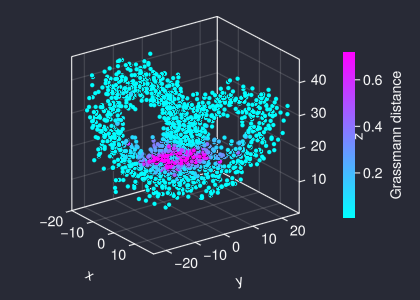

In [71]:
let
    fig = Figure(size=(420,300))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    plt = scatter!(ax,pts,color=clip(ddh.vgrass,0.05),markersize=6,colormap=:cool)
    Colorbar(fig[1,2],plt,label="Grassmann distance",height=Relative(0.7))
    fig
end

## Local dynamics

2-element Vector{ComplexF64}:
 -0.183108290101909 + 17.304382801235416im
 -0.183108290101909 - 17.304382801235416im

2-element Vector{ComplexF64}:
 -0.183108290101909 + 17.304382801235416im
 -0.183108290101909 - 17.304382801235416im

rank([J * svecs svecs]) = 2


3×2 Matrix{Float64}:
  0.173618  0.46114
 -0.432776  0.857643
  0.845759  0.345038

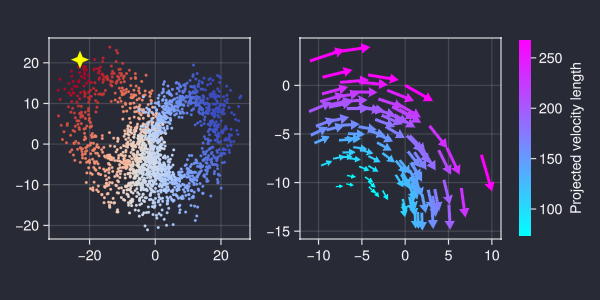

In [72]:
let x = ddh.rot, thr=0.05, nnei=100, cmap=:coolwarm, i=argmax(x), suse=[1,2]
    nei = ddHodge.knn(kdtree,X[:,i],nnei,true)[1]
    S = ddh.spans[i]
    Ψ = ddh.frames[i]
    J = ddh.J[i] # Jacobian matrix in Ψ
    #Jorth = S'*Ψ*J*((Ψ'*Ψ)\(Ψ'*S)) # Jacobian matrix in S
    sf = schur(J)
    display(sf.values)
    svals, svecs = schurselect(sf,suse)
    display(svals)
    @show rank([J*svecs svecs])
    #U = Ψ*rvecs[:,1:2]
    U = Ψ*svecs*diagm([1,-1])
    display(U)
    xoi = U'*(X[:,nei].-X[:,i]) |> eachcol .|> Point2f
    voi = U'*V[:,nei] |> eachcol .|> Point2f
    vali = x[nei]
    vmax = clipmax(x,p=thr)
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=1)
    scatter!(ax1,pts2,markersize=4,color=x,colorrange=(-vmax,vmax),colormap=cmap)
    scatter!(ax1,pts2[i],marker=:star4,markersize=20,color=:yellow)
    ax2 = Axis(fig[1,2],aspect=1)
    α = 0.1*((x,y) -> norm(x-y))(extrema(xoi)...)/median(norm.(voi))
    arr = arrows2d!(ax2,xoi,α*voi,color=clip(norm.(voi),thr),tipwidth=10,colormap=:cool)
    sca = scatter!(ax2,xoi,color=vali,colormap=cmap,markersize=0,colorrange=(-vmax,vmax))
    Colorbar(fig[1,3],arr,height=Relative(0.8),label="Projected velocity length")
    fig
end
#end

In [73]:
if par.d == 3
fig = let x = ddh.rot, thr=0.05, nnei=200, cmap=:coolwarm, suse=[2,3], i=argmax(ddh.rot) #findfirst((ddh.rot .> 40) .& (X[3,:] .> 20))
    nei = ddHodge.knn(kdtree,X[:,i],nnei,true)[1]
    B = ddh.spans[i]
    J = basischange(ddh.J[i],ddh.frames[i],B)
    sf = schur(J)
    display(sf.values)
    svals, svecs = schurselect(sf,suse)
    display(svals)
    @show rank([J*svecs svecs])
    U = B*svecs
    rps = Point3f.(eachcol(10U))
    nv = normalize(U[:,1] × U[:,2])
    @show rps, nv
    b = pts[i]
    vmax = clipmax(x,p=thr)
    fig = Figure(size=(400,300))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    #ax = Axis3(fig[1,1],azimuth=-0.2pi)
    scatter!(ax,pts,color=ddh.rot,transparency=true,markersize=6,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=false)
    arrows2d!(ax,[b,b],Point3f.([0.5rps[1],0.5rps[2]]),shaftwidth=0.5,arrowsize=3,color=[:salmon,:skyblue],transparency=false)
    #arrows!(ax,[b,b,b],Point3f.([0.5rps[1],0.5rps[2],10nv]),linewidth=0.5,arrowsize=2,color=[:salmon,:skyblue,:purple],transparency=true)
    #arrows!(ax,[b,b,b],Point3f.([0.5rps[1],0.5rps[2],0.5nv]),color=[:salmon,:skyblue],linewidth=0.5,arrowsize=2,rasterize=true)
    for (a1,a2) = [(1,1),(1,-1),(-1,1),(-1,-1)]
        mesh!(ax,Point3f.([b,a1*rps[1]+b,a2*rps[2]+b]),color=(:lightgrey,0.5),transparency=true,shading=NoShading)
    end
    fig
end
end

## 1st order taylor approximation
$\bm f(\bm x) \approx \bm f(\bm x_0) + J(\bm x_0)\bm x$

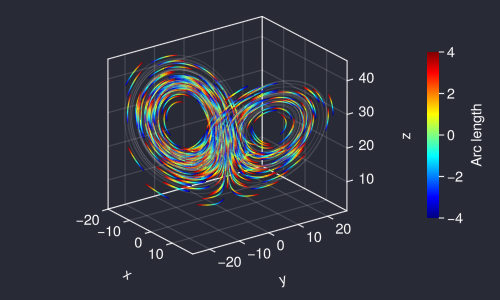

In [74]:
fig = let i = argmin(ddh.rot), ns=40, dt=0.1
    fig = Figure(size=(500,300))
    ax = ax3d(fig[1,1],azymuth=-0.2pi)
    #scatter!(ax,pts,markersize=4,color=(:white,0.6),transparency=true)
    for i in sample(1:N,10)
        lines!(ax,Point3f.(eachcol(trajs[i][:,50:end])),color=:white,transparency=true,linewidth=0.1)
    end
    ln = []
    for j in sample(1:N,500)
        B = ddh.spans[j] # can be i
        Jp = basischange(ddh.J[j],ddh.frames[j],B)
        fp = B'*V[:,j]
        trajbw, trajfw = [
            # velocities are normalized to force unit arc length
            kutta(x -> normalize(fp + Jp*x),fill(0.0,ddh.rdim),s=ns,dt=dt*dir) for dir=[-1,1]
        ]
        traj = B*hcat(reverse(trajbw,dims=2),trajfw[:,2:end]) .+ X[:,j]
        ln = lines!(ax,traj[1:3,:],color=dt.*(-ns:ns),colormap=:jet,linewidth=1,transparency=true)
        #scatter!(ax,Point{ddh.rdim,Float32}(X[:,i]),markersize=4,color=:white)
    end
    Colorbar(fig[1,2],ln,height=Relative(0.7),label="Arc length")
    fig
end

## Run dynamo

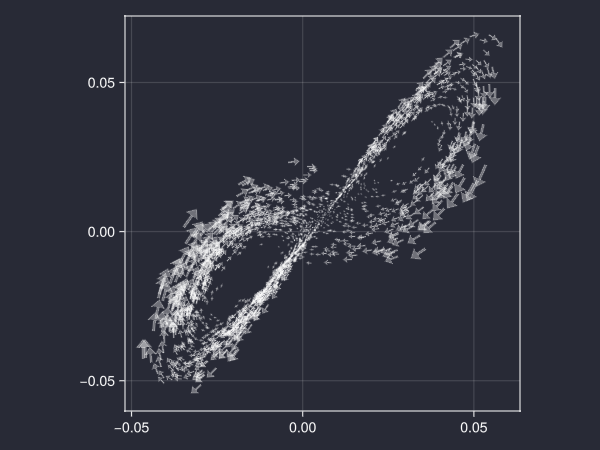

In [75]:
# Normalizing is required to prevent collapsing
Xn, Vn = let
    Xc = X .- μ
    rn = norm.(eachrow(Xc))
    D = diagm(rn.^-1)
    D*Xc, D*V
end
arrows2d(
    Point2f.(eachcol(Xn)),
    0.01Point2f.((eachcol(Vn))),
    color=(:white,0.33), axis=(;aspect=1)
)

In [76]:
import Muon
adata = Muon.AnnData(X=Xn',layers=Dict("velocity" => Vn'))
h5file = "../data/sim3D_$(modelname).h5ad"
Muon.writeh5ad(h5file,adata)

In [ ]:
python = "/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/bin/python" # virtual env. python
run(`$python ../tools/dynamo_nopca.py $h5file`)
adata = Muon.readh5ad(h5file) # reload

/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [10.9186s]
|-----> [VectorField] completed [11.0230s]


Calculating 3-D curl:   0%|                           | 0/2000 [00:00<?, ?it/s]

|-----> [Calculating divergence with precomputed Jacobians] in progress: 100.0000%|-----> [Calculating divergence with precomputed Jacobians] completed [0.0188s]
AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'jacobian_det_pca', 'curl_pca', 'divergence_pca'
    var: 'use_for_dynamics'
    uns: 'PCs', 'VecFld_pca', 'jacobian_pca'
    obsm: 'X_pca', 'velocity_pca', 'velocity_pca_SparseVFC', 'X_pca_SparseVFC', 'curl_pca'
    layers: 'velocity'


Calculating 3-D curl: 100%|█████████████| 2000/2000 [00:00<00:00, 22497.17it/s]
Calculating divergence: 0it [00:00, ?it/s]


AnnData object 2000 ✕ 3

In [78]:
det(ddh.spans[1]'ddh.planes[1]) # check face orientation

0.9999503859190235

extrema(tr.(Ja)) = (-13.666666666666666, -13.666666666666666)
extrema(det.(Ja)) = (-7088.2004319730795, 568.3724365110876)


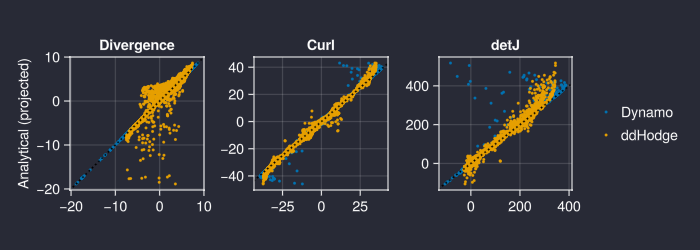

In [79]:
let ms = 4, lc = :black
    Q = [0.0 1.0; -1.0 0.0]
    #Q = [0.0 1.0 0.0; -1.0 0.0 0.0; 0.0 0.0 1.0]
    E = Matrix{Float64}(I,3,3) # cannonical basis
    Ja = Jf.(pts)
    @show extrema(tr.(Ja))
    @show extrema(det.(Ja))
    # Projected Jacobians
    Jp = [basischange(J,E,S) for (J,S) in zip(Ja,ddh.spans)]
    Jdyn = [adata.uns["jacobian_pca"]["jacobian"][:,:,i] for i in 1:N]
    Jpdyn = [basischange(J,E,S) for (J,S) in zip(Jdyn,ddh.spans)]
    fig = Figure(size=(700,250))
    titles = ["Divergence", "Curl", "detJ"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:length(titles)]
    axs[1].ylabel = "Analytical (projected)"
    anavals = [tr.(Jp), [tr(Q*J) for J in Jp], det.(Jp)]
    ddhvals = [ddh.div, ddh.rot, det.(ddh.J)]
    #dynvals = [adata.obs[!,x] for x in ["divergence_pca", "curl_pca", "jacobian_det_pca"]]
    dynvals = [tr.(Jp), [tr(Q*J) for J in Jpdyn], det.(Jpdyn)]
    for i in 1:length(titles)
        scatter!(axs[i], dynvals[i], anavals[i], markersize=ms, label="Dynamo",  rasterize=2)
        scatter!(axs[i], ddhvals[i], anavals[i], markersize=ms, label="ddHodge", rasterize=2)
        ablines!(axs[i], [0], [1], color=lc, linestyle=:dot)
    end
    Legend(fig[1,4],axs[1],markersize=10)
    fig
end

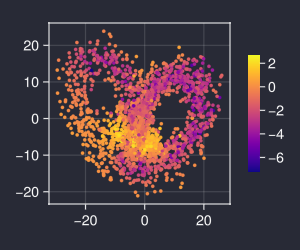

In [80]:
let
    I3 = Matrix{Float64}(I,3,3) # cannonical basis
    J2 = [basischange(Jf(pts[i]),I3,ddh.spans[i]) for i in 1:N]
    #err = [log10(sum(abs2.(Ja[i] - ddh.J[i]))) for i in 1:N]
    err = abs2.(ddh.div - tr.(J2))
    fig = Figure(size=(300,250))
    ax = Axis(fig[1,1],aspect=1)
    sc = scatter!(ax, pts2, color=log10.(err), rasterize=2, markersize=5,colormap=:plasma)
    Colorbar(fig[1,2],sc,height=Relative(0.6))
    fig
end

## Upscaling dimension ... may be usable

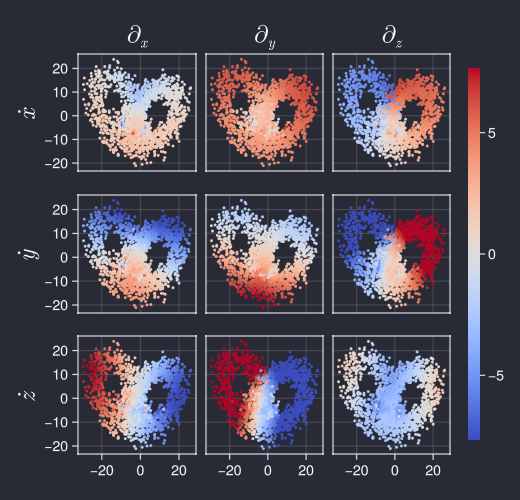

In [81]:
let analytical=false, axes=false, fdim=3
    α = 0.5maximum(norm.(pts2))
    if analytical
        Js = Jf.(eachcol(X))
    else
        E = Matrix{Float64}(I,3,3) # cannonical basis
        Js = [basischange(ddh.J[i],ddh.frames[i],E) for i in 1:N] # upscale
        #Js = [adata.uns["jacobian_pca"]["jacobian"][:,:,i] for i in 1:N] # Dynamo Jacobian
    end
    vmax = clipmax(vec(stack(Js)),p=0.05)
    fig = Figure(size=(520,500))
    axs = [Axis(fig[i,j],aspect=1,titlesize=24,ylabelsize=24) for i in 1:fdim, j in 1:fdim]
    for i in 1:fdim, j in 1:fdim
        vals = [J[i,j] for J in Js]
        scatter!(axs[i,j],pts2,color=vals,colormap=:coolwarm,colorrange=(-vmax,vmax),markersize=4,rasterize=2)
        if axes
            arrows2d!(axs[i,j],fill(Point2f(0),fdim),eachrow(α*S),color=:white)
            text!(axs[i,j],Point2f.(eachrow(α*S)),text=varnames,color=:yellow,fontsize=24,)#font="Bold")
        end
    end
    [axs[i,1].ylabel=L"\dot{%$(varnames[i])}" for i in 1:fdim]
    [axs[1,j].title=L"\partial_{%$(varnames[j])}" for j in 1:fdim]
    linkaxes!(axs...)
    colgap!(fig.layout,10)
    rowgap!(fig.layout,10)
    hideydecorations!.(axs[:,2:fdim], grid = false)
    hidexdecorations!.(axs[1:fdim-1,:], grid = false)
    Colorbar(fig[1:fdim,fdim+1],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.9),vertical=true)
    fig
end

## Jacobian approximation in the tangent space

Ritz method (projection) succeeds if the projected subspace $S$ matches to the invariant subspace: $JS \subseteq S$.

### Nonnormality

median(vals) = 0.3978002283877743


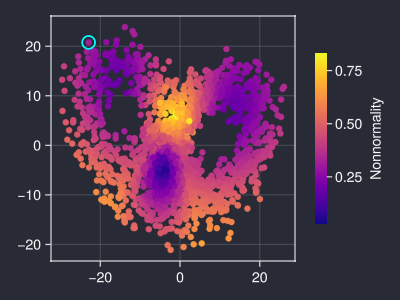

In [82]:
function nonnormality(M; normalize::Bool=true)
    T = schur(complex(M)).T
    off = triu(T, 1) # strictly upper
    d = norm(off)    # = sqrt(∑|off|^2)
    normalize ? d/norm(M) : d
end

let i = argmax(ddh.rot)
    J3 = Jf.(pts)
    vals = nonnormality.(J3)
    #vals = [det(schur(J).Z[:,[1,3,2]]) for J in J3] 
    #vals = [abs(det([ddh.spans[i] schur(J3[i]).Z[:,1]])) for i in 1:N]
    @show median(vals)
    fig = Figure(size=(400,300))
    ax = Axis(fig[1,1],aspect=1)
    sc = scatter!(pts2,color=vals,colormap=:plasma,rasterize=2)
    scatter!(pts2[i],color=:transparent,markersize=15,strokewidth=2,strokecolor=:cyan)
    Colorbar(fig[1,2],sc,label="Nonnormality",height=Relative(0.7))
    fig
    #stairs(sort(vals))
end

### Pseudospectrum

nonnormality(J) = 0.3185687739492686
norm(J * S - S * Jddh) = 6.290135907053424
rank([J * S S]) = 3
evals = ComplexF64[-13.666069758310964 + 0.0im, -0.00029845417785256956 - 21.12004954624126im, -0.00029845417785256956 + 21.12004954624126im]


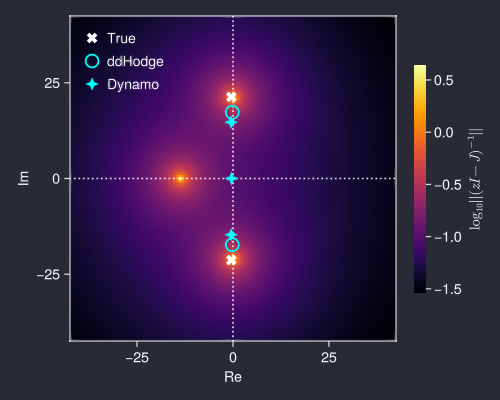

In [83]:
let i = argmax(ddh.rot), nx=200
    J = Jf(pts[i])
    #@show norm(J'J - J*J') / norm(J)^2 # normalized commutator norm
    @show nonnormality(J)
    S = ddh.spans[i]
    E = Matrix(1.0I,3,3)
    Jdyn = adata.uns["jacobian_pca"]["jacobian"][:,:,i]
    Jp = basischange(J,E,S)
    Jddh = basischange(ddh.J[i],ddh.frames[i],S)
    @show norm(J*S - S*Jddh) # Ritz values
    @show rank([J*S S]) # JS ⊈ S
    fig = Figure(size=(500,400))
    ax = Axis(fig[1,1],xlabel="Re",ylabel="Im",aspect=DataAspect())
    evals = eigvals(J)
    @show evals
    zmax = 2*maximum(norm.(evals))
    H = [norm((z*I - J)^-1) for z in range(-zmax,zmax,length=nx) .+ im*range(-zmax,zmax,length=nx)']
    hm = heatmap!(ax,range(-zmax,zmax,length=nx),range(-zmax,zmax,length=nx),log10.(H),colormap=:inferno,rasterize=2)
    #circle = GLMakie.GeometryBasics.Circle(Point2f(0,0),maximum(norm.(evals)))
    #lines!(circle,color=:white,linestyle=:dash)
    hlines!(ax,[0],color=:white,linestyle=:dot)
    vlines!(ax,[0],color=:white,linestyle=:dot)
    #scatter!(reim.(evals),color=:black,markersize=10,label="Analytical")
    scatter!(reim.(eigvals(Jp)),marker=:xcross,markersize=15,color=:white,label="True")
    scatter!(reim.(eigvals(Jddh)),markersize=15,color=:transparent,strokecolor=:cyan,strokewidth=2,label="ddHodge")
    scatter!(reim.(eigvals(Jdyn)),markersize=15,marker=:star4,label="Dynamo",color=:cyan)
    axislegend(position=:lt)
    Colorbar(fig[1,2],hm,height=Relative(0.7),label=L"\log_{10}||(zI-J)^{-1}||")
    fig
end

(tr(Jp), det(Jp)) = (-0.366216580203822, 299.47519277759613)


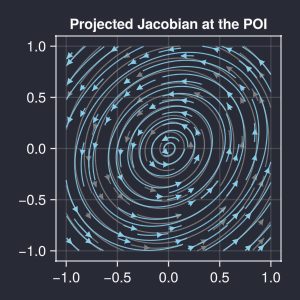

In [84]:
let i = argmax(ddh.rot)
    Jp = ddh.J[i]
    E3 = Matrix(1.0I,3,3)
    J3 = Jf(pts[i])
    J2 = basischange(J3,E3,ddh.spans[i])
    @show tr(Jp), det(Jp)
    fig = Figure(size=(300,300))
    ax = Axis(fig[1,1],aspect=1,title="Projected Jacobian at the POI")
    streamplot!(
        x -> Point2f(J2*x), -1..1, -1..1, density=0.8,
        linewidth=1, arrow_size=8, colormap=[:grey],
    )
    streamplot!(
        x -> Point2f(Jp*x), -1..1, -1..1, density=0.8,
        linewidth=1, arrow_size=8, colormap=[:skyblue],
    )
    fig
end